# PolarGAP aeromagnetic levelling

In [31]:
# %load_ext autoreload
# %autoreload 2


import logging

import cmocean
import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import verde as vd

import airbornegeo

# setup logging to get some additional info from the airbornegeo functions
logging.getLogger("airbornegeo").setLevel("INFO")
logging.basicConfig()

## Load data

In [32]:
data_df = pd.read_csv("data/PolarGAP_magnetic_survey.csv")

data_df = data_df.drop(columns="line")

data_df = data_df.rename(
    columns={"MagB30RTC": "unlevelled_tfa", "MagL_B30RTC": "published_levelled_tfa"}
)


data_df = data_df.sort_values(["flight", "unixtime"])
# convert dataframe into geodataframe
data_df = gpd.GeoDataFrame(
    data_df,
    geometry=gpd.points_from_xy(data_df.easting, data_df.northing),
    crs="EPSG:3031",
)

data_df.head()

,Line,Lon,Lat,Elev,date,Time_UTC,MagR,MagC,Tcorr,RefField,...,unlevelled_tfa,published_levelled_tfa,easting,northing,unixtime,flight,distance_along_flight,distance_along_line,published_levelling_correction,geometry
0,P03.1,-44.480694,-80.441398,131.48,2015-12-15,0 days 17:48:04,47687.3792,47688.29,0.0,47798.3,...,NaN,NaN,-729314.730339,742656.452995,1.450202e+09,1,0.000000,0.000000,NaN,POINT (-729314.73 742656.453)
1,P03.1,-44.482024,-80.441687,132.03,2015-12-15,0 days 17:48:05,47689.7448,47688.64,0.0,47798.6,...,NaN,NaN,-729309.819815,742616.969634,1.450202e+09,1,39.787549,39.787549,NaN,POINT (-729309.82 742616.97)
2,P03.1,-44.483376,-80.441986,132.76,2015-12-15,0 days 17:48:06,47689.7208,47688.92,0.0,47798.9,...,NaN,NaN,-729304.426553,742576.426492,1.450202e+09,1,80.687837,80.687837,NaN,POINT (-729304.427 742576.426)
3,P03.1,-44.484744,-80.442292,133.96,2015-12-15,0 days 17:48:07,47690.7116,47689.12,0.0,47799.2,...,NaN,NaN,-729298.702629,742535.134113,1.450202e+09,1,122.375052,122.375052,NaN,POINT (-729298.703 742535.134)
4,P03.1,-44.486123,-80.442606,135.51,2015-12-15,0 days 17:48:08,47689.7556,47689.25,0.0,47799.5,...,NaN,NaN,-729292.506529,742493.078148,1.450202e+09,1,164.885002,164.885002,NaN,POINT (-729292.507 742493.078)


In [33]:
data_df.columns

Index(['Line', 'Lon', 'Lat', 'Elev', 'date', 'Time_UTC', 'MagR', 'MagC',
       'Tcorr', 'RefField', 'MagRTC', 'Bcorr_60min', 'Bcorr_30min',
       'MagB60RTC', 'unlevelled_tfa', 'published_levelled_tfa', 'easting',
       'northing', 'unixtime', 'flight', 'distance_along_flight',
       'distance_along_line', 'published_levelling_correction', 'geometry'],
      dtype='str')

In [34]:
data_df.describe()

,Lon,Lat,Elev,MagR,MagC,Tcorr,RefField,MagRTC,Bcorr_60min,Bcorr_30min,MagB60RTC,unlevelled_tfa,published_levelled_tfa,easting,northing,unixtime,flight,distance_along_flight,distance_along_line,published_levelling_correction
count,560167.000000,560167.000000,560167.000000,560167.000000,542803.000000,545338.000000,560167.000000,542803.000000,560166.000000,521655.000000,542802.000000,522265.000000,522263.000000,560167.000000,560167.000000,5.601670e+05,560167.000000,5.601670e+05,5.601670e+05,522263.000000
mean,-22.666029,-86.147723,2916.017281,53021.696145,53016.835123,-18.675374,53044.626554,-41.528796,-33.841691,-33.581347,-8.343020,-6.728692,-7.477536,-102286.302030,203124.051734,1.451704e+09,18.619899,4.842424e+05,2.245701e+05,-0.748906
std,75.189642,2.152358,457.949070,2120.134321,2123.642185,48.027996,2135.054349,106.356901,74.001941,75.415269,80.130212,80.304888,78.016381,290124.579775,307205.887303,9.056959e+05,10.342685,2.953373e+05,1.888804e+05,23.160425
min,-179.737553,-89.999904,131.480000,47687.379200,47688.290000,-187.000000,47798.300000,-497.980000,-316.420000,-347.920000,-344.880000,-358.840000,-358.840000,-729314.730339,-486231.648493,1.450202e+09,1.000000,0.000000e+00,0.000000e+00,-165.530000
25%,-80.844587,-87.919588,2804.540000,51409.472000,51421.345000,0.000000,51430.450000,-98.440000,-62.840000,-62.480000,-61.650000,-60.180000,-59.230000,-365765.996690,-13159.054249,1.451050e+09,10.000000,2.327167e+05,6.548865e+04,-10.910000
50%,-30.000391,-85.821818,2925.860000,53150.234200,53125.850000,0.000000,53159.000000,-40.600000,-9.600000,-9.720000,-23.220000,-21.590000,-22.400000,-49757.646526,138347.955425,1.451604e+09,18.000000,4.696834e+05,1.820705e+05,0.000000
75%,20.482409,-84.601775,3210.600000,54625.244700,54618.950000,0.000000,54677.900000,22.050000,7.320000,7.600000,32.447500,33.820000,29.000000,136488.031554,440661.125330,1.452480e+09,28.000000,7.260702e+05,3.460352e+05,9.100000
max,179.862364,-80.441398,4326.720000,58030.806400,58030.540000,0.000000,58037.100000,546.870000,241.190000,255.400000,538.020000,535.700000,545.790000,481434.079137,876179.642440,1.453326e+09,36.000000,1.101909e+06,1.015360e+06,154.840000


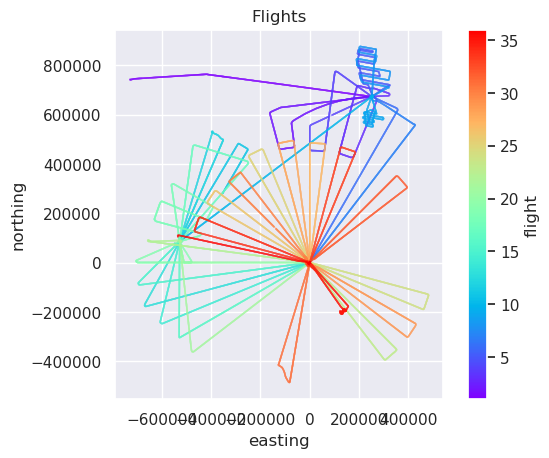

In [35]:
data_df[::20].plot.scatter(
    "easting",
    "northing",
    c="flight",
    s=0.02,
    cmap="rainbow",
    title="Flights",
).set_aspect("equal")

# Cross-over levelling

## Find intersections

In [36]:
# calculate theoretical intersection points
inters = airbornegeo.create_intersection_table(
    data_df,
    line_column="flight",
    method="network",
)
inters

Line pairs:   0%|          | 0/630 [00:00<?, ?it/s]

INFO:airbornegeo:found 302 intersections


,line1,line2,geometry,max_dist,easting,northing
0,1,2,POINT (246812 673168),19.462708,246812.0,673168.0
1,1,3,POINT (249991 672757),0.814955,249991.0,672757.0
2,1,4,POINT (249744 674134),2.543118,249744.0,674134.0
3,1,5,POINT (250759 674842),8.680413,250759.0,674842.0
4,1,6,POINT (255166 673855),24.330477,255166.0,673855.0
...,...,...,...,...,...,...
297,33,35,POINT (-1278 -1888),6.427474,-1278.0,-1888.0
298,33,36,POINT (-5672 -4909),14.604755,-5672.0,-4909.0
299,34,35,POINT (-2320 -4391),4.665483,-2320.0,-4391.0
300,34,36,POINT (-1426 -2129),0.695396,-1426.0,-2129.0


In [37]:
# see which lines don't have intersections
airbornegeo.lines_without_intersections(data_df, inters, line_column="flight")

[]

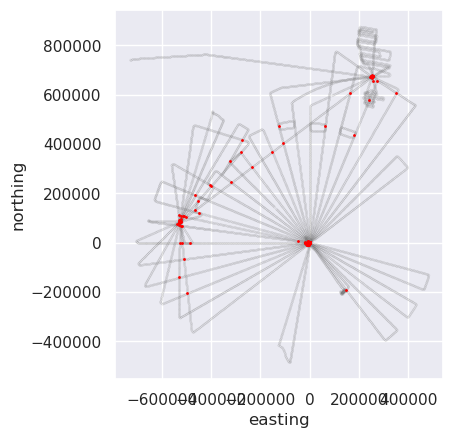

In [38]:
ax = data_df[::20].plot.scatter(
    "easting",
    "northing",
    color="gray",
    s=0.001,
)
inters.plot.scatter(
    "easting",
    "northing",
    color="red",
    s=1,
    ax=ax,
)
ax.set_aspect("equal")

## Add intersections as rows to the dataframe

In [39]:
data_df, inters = airbornegeo.interpolate_intersections(
    data_df,
    inters,
    line_column="flight",
    to_interp="unlevelled_tfa",
    interp_on="distance_along_flight",
    # window_width=500,
    method="cubic",
    extrapolate=True,
)
inters

Interpolating segments:   0%|          | 0/36 [00:00<?, ?it/s]

,line1,line2,geometry,max_dist,easting,northing,dist_along_line1,dist_along_line2,line1_interpolation_type,line2_interpolation_type
0,1,2,POINT (246812 673168),19.462708,246812.0,673168.0,984289.163810,417647.819322,interpolated,interpolated
1,1,3,POINT (249991 672757),0.814955,249991.0,672757.0,987494.321016,76169.608679,interpolated,interpolated
2,1,4,POINT (249744 674134),2.543118,249744.0,674134.0,987267.992044,178861.571269,interpolated,interpolated
3,1,5,POINT (250759 674842),8.680413,250759.0,674842.0,988413.092913,20588.131420,interpolated,interpolated
4,1,6,POINT (255166 673855),24.330477,255166.0,673855.0,992637.541790,3798.771200,interpolated,interpolated
...,...,...,...,...,...,...,...,...,...,...
297,33,35,POINT (-1278 -1888),6.427474,-1278.0,-1888.0,487151.377659,11957.568038,interpolated,interpolated
298,33,36,POINT (-5672 -4909),14.604755,-5672.0,-4909.0,492042.840269,65130.088157,interpolated,interpolated
299,34,35,POINT (-2320 -4391),4.665483,-2320.0,-4391.0,42114.843174,9342.344658,interpolated,interpolated
300,34,36,POINT (-1426 -2129),0.695396,-1426.0,-2129.0,41756.085925,68395.818716,interpolated,interpolated


In [40]:
# see which lines don't have intersections
airbornegeo.lines_without_intersections(data_df, inters, line_column="flight")

[]

## Calculate initial cross-over errors

In [41]:
inters = airbornegeo.calculate_crossover_errors(
    data_df,
    inters,
    data_col="unlevelled_tfa",
    line_column="flight",
)
inters.head()

,line1,line2,geometry,max_dist,easting,northing,dist_along_line1,dist_along_line2,line1_interpolation_type,line2_interpolation_type,mistie_0
0,1,2,POINT (246812 673168),19.462708,246812.0,673168.0,984289.163810,417647.819322,interpolated,interpolated,53.85
1,1,3,POINT (249991 672757),0.814955,249991.0,672757.0,987494.321016,76169.608679,interpolated,interpolated,59.79
2,1,4,POINT (249744 674134),2.543118,249744.0,674134.0,987267.992044,178861.571269,interpolated,interpolated,72.69
3,1,5,POINT (250759 674842),8.680413,250759.0,674842.0,988413.092913,20588.131420,interpolated,interpolated,77.04
4,1,6,POINT (255166 673855),24.330477,255166.0,673855.0,992637.541790,3798.771200,interpolated,interpolated,126.17


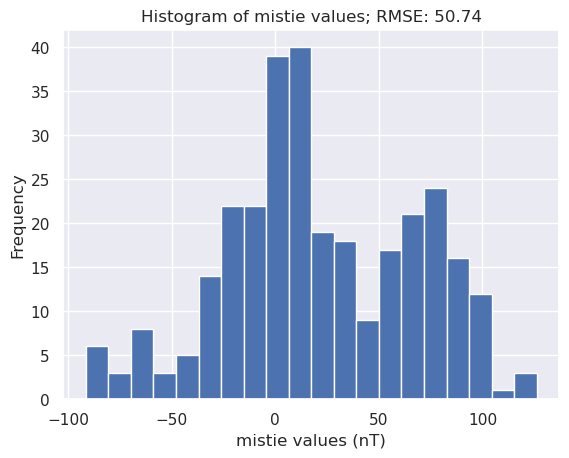

In [42]:
ax = inters.mistie_0.plot.hist(bins=20)
ax.set_xlabel("mistie values (nT)")
ax.set_title(
    f"Histogram of mistie values; RMSE: {round(airbornegeo.rmse(inters.mistie_0), 2)}"
);

## Level with a trend

  0%|          | 0/20 [00:00<?, ?it/s]

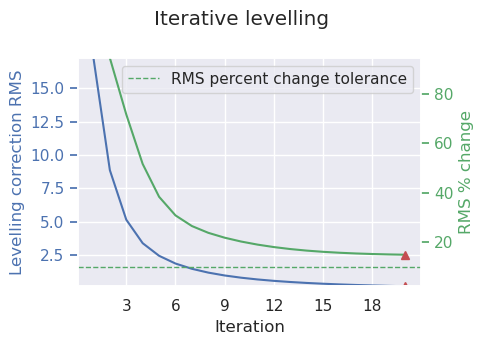

Levelling terminated after 20 iterations with RMS of levelling correction of 0.18 because maximum number of iterations (20) reached.


In [43]:
data_df, inters_trend = airbornegeo.crossover_network_levelling(
    data_df,
    inters,
    data_col="unlevelled_tfa",
    levelled_col="levelled_trend",
    line_column="flight",
    degree=0,
    max_iterations=20,
    plot_dynamic_levelling_convergence=True,
)

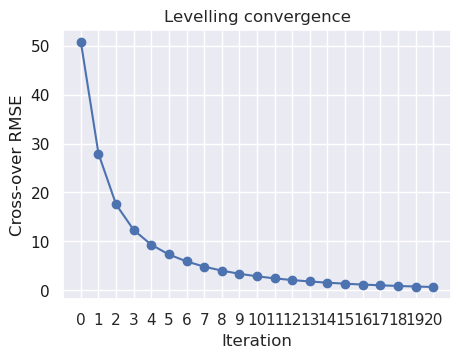

In [44]:
airbornegeo.plot_levelling_convergence(inters_trend)

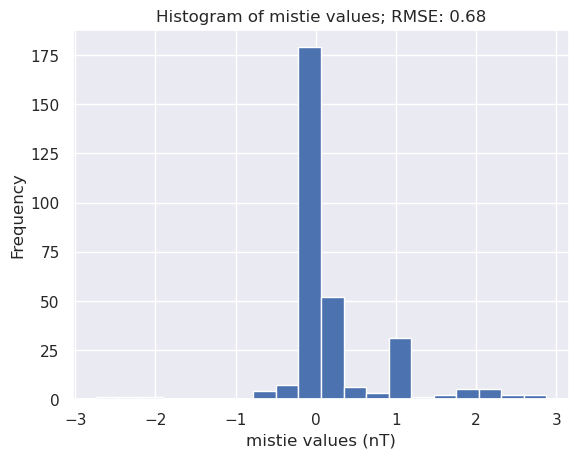

In [45]:
ax = inters_trend[inters_trend.columns[-1]].plot.hist(bins=20)
ax.set_xlabel("mistie values (nT)")
ax.set_title(
    f"Histogram of mistie values; RMSE: {round(airbornegeo.rmse(inters_trend[inters_trend.columns[-1]]), 2)}"
);

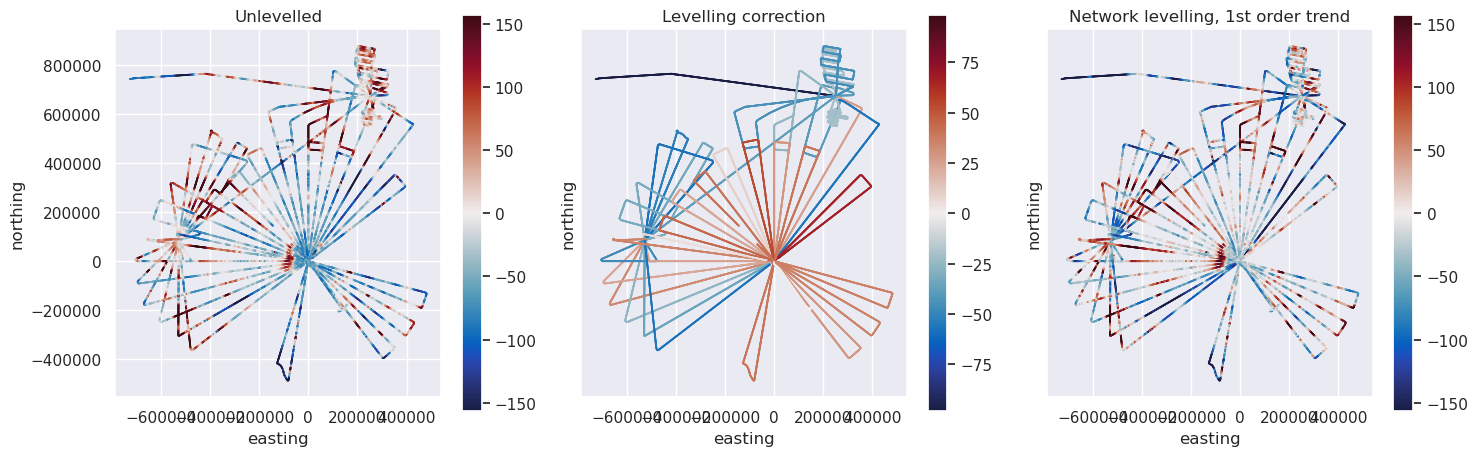

In [46]:
fig, axs = plt.subplots(1, 3, figsize=(15, 40))

data_df["levelling_correction"] = data_df.levelled_trend - data_df.unlevelled_tfa
df = data_df[::20]

max_abs = vd.maxabs(df.unlevelled_tfa, percentile=95)
ax = df.plot.scatter(
    "easting",
    "northing",
    c="unlevelled_tfa",
    s=0.1,
    ax=axs[0],
    cmap=cmocean.cm.balance,
    vmin=-max_abs,
    vmax=max_abs,
    colorbar=False,
    title="Unlevelled",
)
ax.set_aspect("equal")
plt.colorbar(ax.collections[0], ax=ax, shrink=0.1)

max_abs_level_corr = vd.maxabs(df.levelling_correction, percentile=99.5)
ax = df.plot.scatter(
    "easting",
    "northing",
    c="levelling_correction",
    s=0.1,
    ax=axs[1],
    cmap=cmocean.cm.balance,
    vmin=-max_abs_level_corr,
    vmax=max_abs_level_corr,
    colorbar=False,
    title="Levelling correction",
)
ax.set_yticks([])
ax.set_aspect("equal")
plt.colorbar(ax.collections[0], ax=ax, shrink=0.1)

ax = df.plot.scatter(
    "easting",
    "northing",
    c="levelled_trend",
    s=0.1,
    ax=axs[2],
    cmap=cmocean.cm.balance,
    vmin=-max_abs,
    vmax=max_abs,
    colorbar=False,
    title="Network levelling, 1st order trend",
)
ax.set_yticks([])
ax.set_aspect("equal")
plt.colorbar(ax.collections[0], ax=ax, shrink=0.1)

plt.tight_layout()
plt.show()

## Level with a filter

  0%|          | 0/20 [00:00<?, ?it/s]

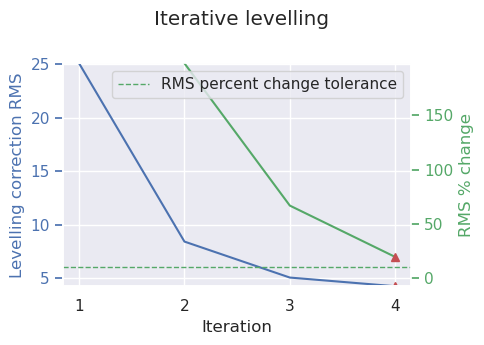

INFO:airbornegeo:
Levelling terminated after 4 iterations because the RMS of the cross-over errors (4.2310919463585694) began to increase.


In [47]:
data_df, inters_filter = airbornegeo.crossover_network_levelling(
    data_df,
    inters,
    data_col="unlevelled_tfa",
    levelled_col="levelled_filter",
    line_column="flight",
    filter="g200000",
    max_iterations=20,
    plot_dynamic_levelling_convergence=True,
)

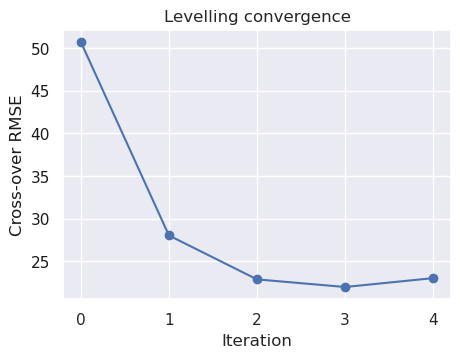

In [48]:
airbornegeo.plot_levelling_convergence(inters_filter)

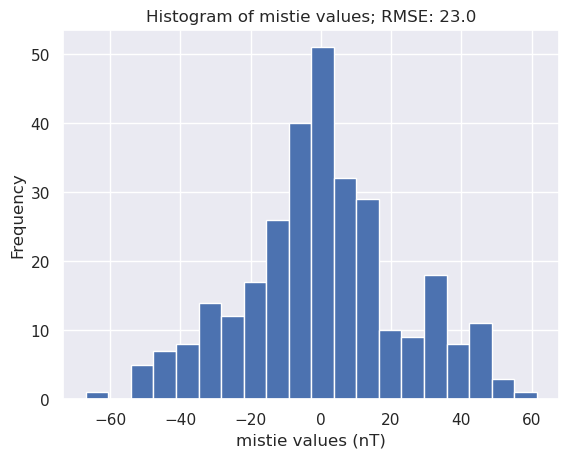

In [49]:
ax = inters_filter[inters_filter.columns[-1]].plot.hist(bins=20)
ax.set_xlabel("mistie values (nT)")
ax.set_title(
    f"Histogram of mistie values; RMSE: {round(airbornegeo.rmse(inters_filter[inters_filter.columns[-1]]), 2)}"
);

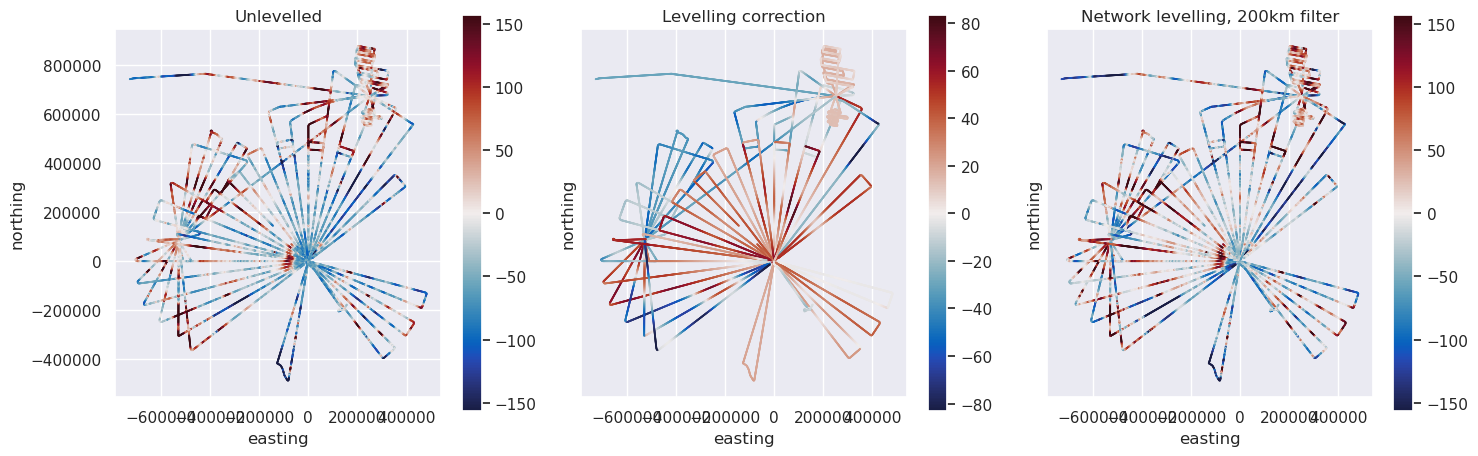

In [50]:
fig, axs = plt.subplots(1, 3, figsize=(15, 40))

data_df["levelling_correction"] = data_df.levelled_filter - data_df.unlevelled_tfa
df = data_df[::20]

max_abs = vd.maxabs(df.unlevelled_tfa, percentile=95)
ax = df.plot.scatter(
    "easting",
    "northing",
    c="unlevelled_tfa",
    s=0.1,
    ax=axs[0],
    cmap=cmocean.cm.balance,
    vmin=-max_abs,
    vmax=max_abs,
    colorbar=False,
    title="Unlevelled",
)
ax.set_aspect("equal")
plt.colorbar(ax.collections[0], ax=ax, shrink=0.1)

max_abs_level_corr = vd.maxabs(df.levelling_correction, percentile=99.5)
ax = df.plot.scatter(
    "easting",
    "northing",
    c="levelling_correction",
    s=0.1,
    ax=axs[1],
    cmap=cmocean.cm.balance,
    vmin=-max_abs_level_corr,
    vmax=max_abs_level_corr,
    colorbar=False,
    title="Levelling correction",
)
ax.set_yticks([])
ax.set_aspect("equal")
plt.colorbar(ax.collections[0], ax=ax, shrink=0.1)

ax = df.plot.scatter(
    "easting",
    "northing",
    c="levelled_filter",
    s=0.1,
    ax=axs[2],
    cmap=cmocean.cm.balance,
    vmin=-max_abs,
    vmax=max_abs,
    colorbar=False,
    title="Network levelling, 200km filter",
)
ax.set_yticks([])
ax.set_aspect("equal")
plt.colorbar(ax.collections[0], ax=ax, shrink=0.1)

plt.tight_layout()
plt.show()

<Axes: ylabel='Frequency'>

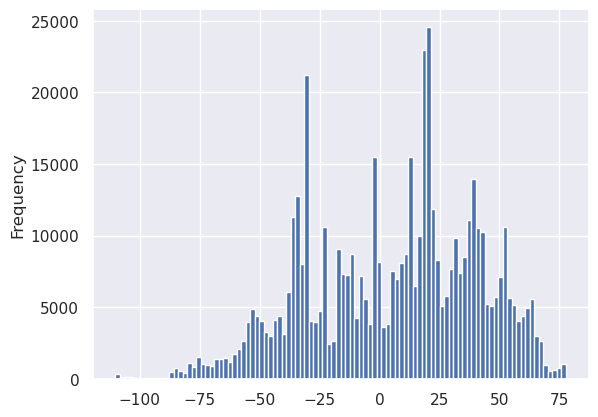

In [51]:
data_df.levelling_correction.plot.hist(bins=100)

In [52]:
# save to csv
data_df.to_csv("data/polargap_magnetics_crossover_levelled.csv", index=False)

In [53]:
levelled_df = pd.read_csv("data/polargap_magnetics_crossover_levelled.csv")

levelled_df = levelled_df[levelled_df.is_intersection == False]
levelled_df = levelled_df.drop(
    columns=[
        "is_intersection",
        "intersecting_line",
        "unlevelled_tfa_interpolation_type",
    ]
)
levelled_df

,Line,Lon,Lat,Elev,date,Time_UTC,MagR,MagC,Tcorr,RefField,...,northing,unixtime,flight,distance_along_flight,distance_along_line,published_levelling_correction,geometry,levelled_trend,levelled_filter,levelling_correction
0,P03.1,-44.447413,-80.462720,413.53,2015-12-15,0 days 17:49:10,47719.3472,47719.89,0.0,47806.6,...,741415.020595,1.450202e+09,1,2966.664991,2966.664991,0.00,POINT (-727250.0956878879 741415.0205951583),-183.225461,-115.223973,-30.493973
1,P03.1,-44.445046,-80.462952,414.58,2015-12-15,0 days 17:49:11,47719.7048,47720.10,0.0,47806.6,...,741426.947780,1.450202e+09,1,3016.511606,3016.511606,0.00,POINT (-727201.6970597674 741426.947780105),-183.045461,-115.043973,-30.493973
2,P03.1,-44.442643,-80.463185,415.50,2015-12-15,0 days 17:49:12,47720.4216,47720.29,0.0,47806.6,...,741439.251031,1.450202e+09,1,3066.975188,3066.975188,0.00,POINT (-727152.756247261 741439.2510305169),-182.855461,-114.853973,-30.493973
3,P03.1,-44.440210,-80.463421,416.89,2015-12-15,0 days 17:49:13,47721.0752,47720.44,0.0,47806.6,...,741451.697915,1.450202e+09,1,3118.072867,3118.072867,0.00,POINT (-727103.1977166379 741451.6979147659),-182.695461,-114.693973,-30.493973
4,P03.1,-44.437754,-80.463660,418.96,2015-12-15,0 days 17:49:14,47720.5770,47720.56,0.0,47806.6,...,741464.199500,1.450202e+09,1,3169.695169,3169.695169,0.00,POINT (-727053.1120655205 741464.1994997265),-182.555461,-114.553973,-30.493973
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
522843,P39,-79.005304,-84.990344,1594.23,2016-01-20,0 days 21:47:23,52678.5008,52678.52,0.0,52845.3,...,103873.551819,1.453326e+09,36,560850.857525,560850.857525,121.65,POINT (-534647.336028793 103873.55181861955),-36.030891,-22.609493,18.070507
522844,P39,-79.011108,-84.990586,1593.23,2016-01-20,0 days 21:47:24,52678.9898,52679.05,0.0,52845.8,...,103814.370783,1.453326e+09,36,560911.994252,560911.994252,121.68,POINT (-534631.9963949411 103814.3707829598),-36.080891,-22.658321,18.071679
522845,P39,-79.016923,-84.990828,1591.87,2016-01-20,0 days 21:47:25,52679.4624,52679.57,0.0,52846.3,...,103755.091283,1.453326e+09,36,560973.222937,560973.222937,121.71,POINT (-534616.6701818157 103755.09128288226),-36.130891,-22.706897,18.073103
522846,P39,-79.022752,-84.991071,1590.41,2016-01-20,0 days 21:47:26,52680.1722,52680.08,0.0,52846.8,...,103695.664609,1.453326e+09,36,561034.616169,561034.616169,121.74,POINT (-534601.2559252244 103695.66460877388),-36.170891,-22.745443,18.074557


## Assessing levelling errors

In [ ]:
# # block reduce the line data
# levelled_df = airbornegeo.block_reduce(
#     levelled_df,
#     np.median,
#     spacing=200,
#     # reduce_by=('easting', 'northing'),
#     reduce_by="distance_along_line",
#     groupby_column="line",
# )
# levelled_df = levelled_df.dropna(
#     subset=["easting", "northing", "height", "unlevelled_tfa"]
# )
# levelled_df

In [ ]:
# # save to csv
# levelled_df.to_csv("data/san_luis_magnetics_crossover_levelled_blocked.csv", index=False)

In [ ]:
# levelled_df = pd.read_csv("data/san_luis_magnetics_crossover_levelled_blocked.csv")
# levelled_df

In [ ]:
# coords = (
#     levelled_df.easting,
#     levelled_df.northing,
#     levelled_df.height,
# )

In [ ]:
# eqs_kwargs = dict(
#     damping=0.01,
#     depth="default",
#     block_size=200,
# )

# eqs_unlevelled = hm.EquivalentSourcesGB(
#     window_size=40e3,
#     random_state=42,
#     **eqs_kwargs,
# )

# # eqs_unlevelled = hm.EquivalentSources(**eqs_kwargs)

# bytes = eqs_unlevelled.estimate_required_memory(coords)
# print(f"{bytes / 1e9} GB ram required")

In [ ]:
# eqs_unlevelled.fit(coords, levelled_df.unlevelled_tfa)

In [ ]:
# # Define grid coordinates
# grid_coords = vd.grid_coordinates(
#     region=vd.pad_region(vd.get_region(coords), 2e3),
#     spacing=100,
#     extra_coords=levelled_df.height.mean(),  # upward continue
#     adjust="region",
# )
# grid_unlevelled = eqs_unlevelled.grid(grid_coords)

# # grid_unlevelled = vd.distance_mask(
# #     (coords[0], coords[1]), maxdist=2e3, grid=grid_unlevelled
# # )
# grid_unlevelled = grid_unlevelled.reset_coords(names="upward").scalars

# grid_unlevelled.plot().axes.set_aspect("equal")

In [ ]:
# import xrft
# powerspec_unlevelled = xrft.power_spectrum(grid_unlevelled)
# powerspec_unlevelled.plot(
#     robust=True,
# )

In [ ]:
# hg_unlevelled = airbornegeo.filter_grid(
#     grid_unlevelled, filter_type="horizontal_gradient"
# )
# hg_unlevelled.plot(robust=True)